# 3. Dataset Curation

In [1]:
import rasterio
import numpy as np
import os
from rasterio.enums import Resampling
from glob import glob
import shutil
import matplotlib.pyplot as plt
from preprocessing_switzerland.preprocessing import preprocess_gletscher_data, PreprocessingConfig
from preprocessing_switzerland.train_val_test_split import setup_and_split_data_nested
import random
from sklearn.model_selection import train_test_split 

## 3.1 Specifications of dataset

### 1. Identification of Dataset

The contextual dataset used for glacier segmentation is derived from Sentinel-2 Level-2A multispectral imagery over the Swiss Alps, publicly accessible through the European Space Agency’s (ESA) Copernicus Programme. This open-data framework ensures ethical data acquisition, full transparency, and long-term reproducibility of the AI workflow. Sentinel-2 offers global coverage at 10–20 m spatial resolution, which is broadly comparable to the Amazon and Atlantic Forest datasets used in the original deforestation study, although underlying terrain characteristics differ substantially.

In the original paper, the Amazon 4-band dataset consisted of approximately 250 training images. To enhance model robustness and achieve more stable performance across diverse glacier conditions, we curated a substantially larger dataset of around 1,000 images. This larger sample improves the model’s ability to distinguish subtle spectral and spatial differences such as ice vs. water, clean ice vs. debris-covered ice, and glacier edges vs. surrounding rock.

Furthermore, while the original study relied on four spectral bands, glacier mapping benefits from additional shortwave infrared bands. Therefore, Bands B11 and B12 were included, which are highly effective for identifying snow and ice, improving the separability of frozen surfaces from water, rock and vegetation. This results in a dataset that is not only larger but also higher in spectral quality for the glacier segmentation task.

Source: https://browser.dataspace.copernicus.eu/

Data owner: European Space Agency (ESA) under the Copernicus Open Data Licence.

### 2. Data Collection Process & Ethical Consideration

The image collection itself was targeted at acquiring scenes over the Swiss Alps. To capture the glaciers clearly and isolate the effect of climate change, only satellite images acquired during the late summer months (July, August and September) were taken into account. These months provide the clearest view of glacier boundaries, as seasonal snow has largely melted and cloud cover is typically lower. Data was collected between 2020 and 2025. To ensure high visible images, the maximum cloud coverage was set to 4% when extracting the data.

From an ethical standpoint:
- No privacy risks: Open-access Sentinel-2 data does not contain personally identifiable information. The imagery represents large-scale alpine landscapes, meaning individuals, communities, and private property cannot be recognised. This avoids common privacy concerns in geospatial AI.

- No exclusion of marginalised groups: The dataset concerns uninhabited high-mountain environments. Since the focus is environmental monitoring rather than human populations, the risk of reinforcing social inequities or excluding vulnerable groups is minimal.

- Transparency and reproducibility: All images originate from publicly available sources (Copernicus Open Access Hub / Sentinel Hub). Every scene can be retrieved by other researchers using identical query parameters, supporting open, verifiable, and collaborative AI development.

- Environmental and computational considerations: Satellite-based monitoring reduces the need for helicopter- or ground-based surveys, thereby lowering environmental disturbance and carbon emissions. The chosen model (Attention U-Net) is comparatively lightweight, helping to minimise computational energy consumption while maintaining strong predictive performance.

- Bias awareness: Although human groups are not affected, the dataset still exhibits environmental bias. For example, selecting only late-summer imagery may cause the model to generalise poorly to early-season or snow-covered conditions.

### 3. Limitations

Despite high-quality imagery, several limitations affect model performance:
- Seasonal bias: Only late-summer images were used. While this reduces snow contamination, it limits the model’s ability to generalise to winter or spring conditions.
- Cloud and shadow interference: Even with strict cloud filtering, alpine shadows and atmospheric haze may reduce image clarity, or misclassifying clouds as ice, leading to segmentation errors.
- Spectral ambiguity: Debris-covered glaciers reflect light very differently from clean ice and resemble surrounding rocks in multispectral bands, making them harder to detect. This is why the model (and the NDSI formula) sometimes cannot distinguish “dirty glacier ice” from surrounding rock.
- Images focus primarily on large, well-known Swiss glaciers (e.g., Aletsch), meaning small or highly fragmented glaciers may be underrepresented.
- The glacier labels are not manually annotated but generated algorithmically using an NDSI threshold (0.25) combined with a NDWI water filter. While computationally efficient, this rule-based approach introduces systematic biases. For example, clean snow may be incorrectly labelled as glacier ice, while debris-covered glacier areas may be missed. This is approach, when taking a look at a sample of 50 images, resulted in general good results. But future work could definitely look at improving label quality.
    - An option was to go for the Swiss Glacier Inventory 2016 dataset, that outlines glaciers, debris and ice coverage in Switzerland during 2013-2018. However, as we wanted to look at more recent satellite images to better see the pressing effects of climate change on glacier melting, we chose to work with more recent images, making the use of this dataset infeasible.
- The masks are based solely on spectral indices rather than elevation or slope information, meaning the model does not receive any geometric or topographic cues that are often essential for distinguishing glacier ice from surrounding landforms. Including such metrics could enhance the data quality for model training.


Due to memory limitations, the dataset originally sourced had to be severly deducted to be able to run the model on the cloud, for GPU Access. The limited amount of data can impact performance of the model.

## 3.2 Preprocessing Pipeline

**1. Global configuration and clean start**
- A `PreprocessingConfig` object defines key parameters:
  - `TILE_SIZE = 512`
  - `NDSI_THRESHOLD = 0.25` (ice/snow threshold)
  - `NDWI_WATER_THRESHOLD = 0.2` (water filter)
  - `EMPTY_TILE_THRESHOLD = 0.95` (≥95% zero pixels → tile discarded)
  - `MIN_ICE_PERCENTAGE = 0.001` (≥0.1% glacier pixels required)

**2. Sentinel-2 scene discovery (.SAFE)**
- The script recursively searches for all `.SAFE` folders.
- For each scene, it identifies the corresponding `GRANULE/*` directory containing the spectral data.
- Scenes without a valid `GRANULE` structure are skipped.  

**3. Band stacking and resampling to 10 m**
- Six spectral bands are loaded:
  - 10 m resolution: `B02`, `B03`, `B04`, `B08`
  - 20 m resolution: `B11`, `B12`
- `B04` is used as the **spatial reference**.
- `B11` and `B12` are **bilinearly resampled** to 10 m so all bands match.
- All six bands are stacked into a single `(H, W, 6)` array.  

**4. Mask generation using NDSI + NDWI**
- Extracted bands:
  - B03 (green), B08 (NIR), B11 (SWIR1)
- All three are normalised by dividing by **10,000** (Sentinel-2 reflectance scale).
- Compute:
  - `NDSI = (B03 − B11) / (B03 + B11 + ε)`
  - `NDWI = (B03 − B08) / (B03 + B08 + ε)`
- A pixel is labelled as **ice** if:
  - `NDSI > 0.25`  
  - `NDWI < 0.2`  
- Output is a binary glacier mask `(H, W, 1)`.  

**5. Input normalisation and tiling (512×512)**
- The stacked Sentinel-2 image is normalised again into `[0, 1]` range by dividing by `10,000`.
- The image and mask are tiled into **512×512** patches (no overlap).  


**6. Tile filtering – No-data rule (≥95% zeros)**
- Count zero-valued pixels across *all channels*.
- If more than **95%** of the tile contains zero/no-data pixels, it is discarded.
- This removes black borders and invalid areas near image edges or completely black images.  

**7. Tile filtering – Glacier coverage rule (0.1–100%)**
- Count glacier pixels in the mask: `ice_pixels = sum(tile_Y)`.
- Two rejection rules:
  - **Reject** tiles with **<0.1% glacier pixels** → (almost no glacier present).  
  - **Reject** tiles with **100% glacier pixels** → (pure ice, no context for learning).  
- This ensures the model trains on **boundary-rich, mixed-content tiles**.  

**8. Saving final tiles (.npy)**
- Tiles passing all filters are saved as NumPy arrays:
  - Inputs → `inputs_X/{sceneID}_{tileIdx}_X.npy`
  - Masks → `masks_Y/{sceneID}_{tileIdx}_Y.npy`
- `sceneID` comes from the Sentinel-2 file naming structure.  

**9. Creation of nested output directories**
- The script creates:
  - `train/X`, `train/Y`
  - `val/X`, `val/Y`
  - `test/X`, `test/Y`
- Ensures a clean, reproducible dataset structure.  

 **10. 80/10/10 train–val–test split**
- All `*_X.npy` tiles are collected and sorted.
- Using `train_test_split`, the dataset is divided into:
  - **80% training**
  - **10% validation**
  - **10% test**
- A fixed `random_state` ensures reproducibility of the splits.  

**11. Copying paired X/Y tiles into split folders**
- Each selected `X` tile path is converted into its corresponding `Y` path by:
  - replacing `inputs_X` → `masks_Y`
  - replacing `_X.npy` → `_Y.npy`
- Valid pairs are copied into:
  - `train/X`, `train/Y`
  - `val/X`, `val/Y`
  - `test/X`, `test/Y`  


This preprocessing pipeline ensures a high-quality, domain-specific glacier segmentation dataset by combining multispectral band stacking, NDSI/NDWI mask generation, strict tile filtering rules, and a reproducible split into training, validation and testing subsets. A few examples of the end result can be found at the bottom of this notebook.

In [2]:
# Run the preprocess pipeline
DATA_ROOT_DIRECTORY = 'data_switzerland'

config = PreprocessingConfig()
preprocess_gletscher_data(DATA_ROOT_DIRECTORY, config)

Found 16 scenes. Starting preprocessing...

--- Processing Scene 1/16: S2A_0210814.SAFE ---
SUMMARY: Tiles saved: 187 | Empty discarded: 2 | Pure discarded: 252

--- Processing Scene 2/16: S2A_20210814.SAFE ---
SUMMARY: Tiles saved: 158 | Empty discarded: 0 | Pure discarded: 283

--- Processing Scene 3/16: S2A_20230824.SAFE ---
SUMMARY: Tiles saved: 95 | Empty discarded: 128 | Pure discarded: 218

--- Processing Scene 4/16: S2A_20241030.SAFE ---
SUMMARY: Tiles saved: 169 | Empty discarded: 17 | Pure discarded: 255

--- Processing Scene 5/16: S2B_20220718.SAFE ---
SUMMARY: Tiles saved: 146 | Empty discarded: 17 | Pure discarded: 278

--- Processing Scene 6/16: S2B_20240714.SAFE ---
SUMMARY: Tiles saved: 49 | Empty discarded: 375 | Pure discarded: 17

--- Processing Scene 7/16: S2B_20240915.SAFE ---
SUMMARY: Tiles saved: 209 | Empty discarded: 0 | Pure discarded: 232

--- Processing Scene 8/16: S2B_20250808.SAFE ---
SUMMARY: Tiles saved: 147 | Empty discarded: 2 | Pure discarded: 292

--

In [3]:
# Splits preprocessed data in train, validation and test data

# Base directory where preprocessed tiles are currently stored
BASE_DIR = 'data_switzerland/preprocessed_data/'
INPUT_DIR_X = os.path.join(BASE_DIR, 'inputs_X')
INPUT_DIR_Y = os.path.join(BASE_DIR, 'masks_Y')

# Define target base split directories (The nesting /X and /Y is handled later)
SPLIT_DIRS_BASE = {
    'train': os.path.join(BASE_DIR, 'train'),
    'val': os.path.join(BASE_DIR, 'val'),
    'test': os.path.join(BASE_DIR, 'test')
}

# Define the split ratios (80% Train, 10% Validation, 10% Test)
TEST_VALIDATION_RATIO = 0.20 # 20% total for validation and test
TEST_SET_RATIO = 0.50        # 50% of the remaining 20% goes to test (i.e., 10%)
RANDOM_SEED = 42             # For reproducibility

setup_and_split_data_nested(INPUT_DIR_X, INPUT_DIR_Y, SPLIT_DIRS_BASE, TEST_VALIDATION_RATIO, TEST_SET_RATIO, RANDOM_SEED) 

Total tiles found: 1002
Training set size: 801 (79.9%)
Validation set size: 100 (10.0%)
Test set size: 101 (10.1%)

SUCCESS: All data has been split and organized into the nested Train/Validation/Test structure.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3008].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.7584].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4856].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1003..1.6304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0984..1.504].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0978..1.8704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4712].
Clipping input data to the valid range for imsh

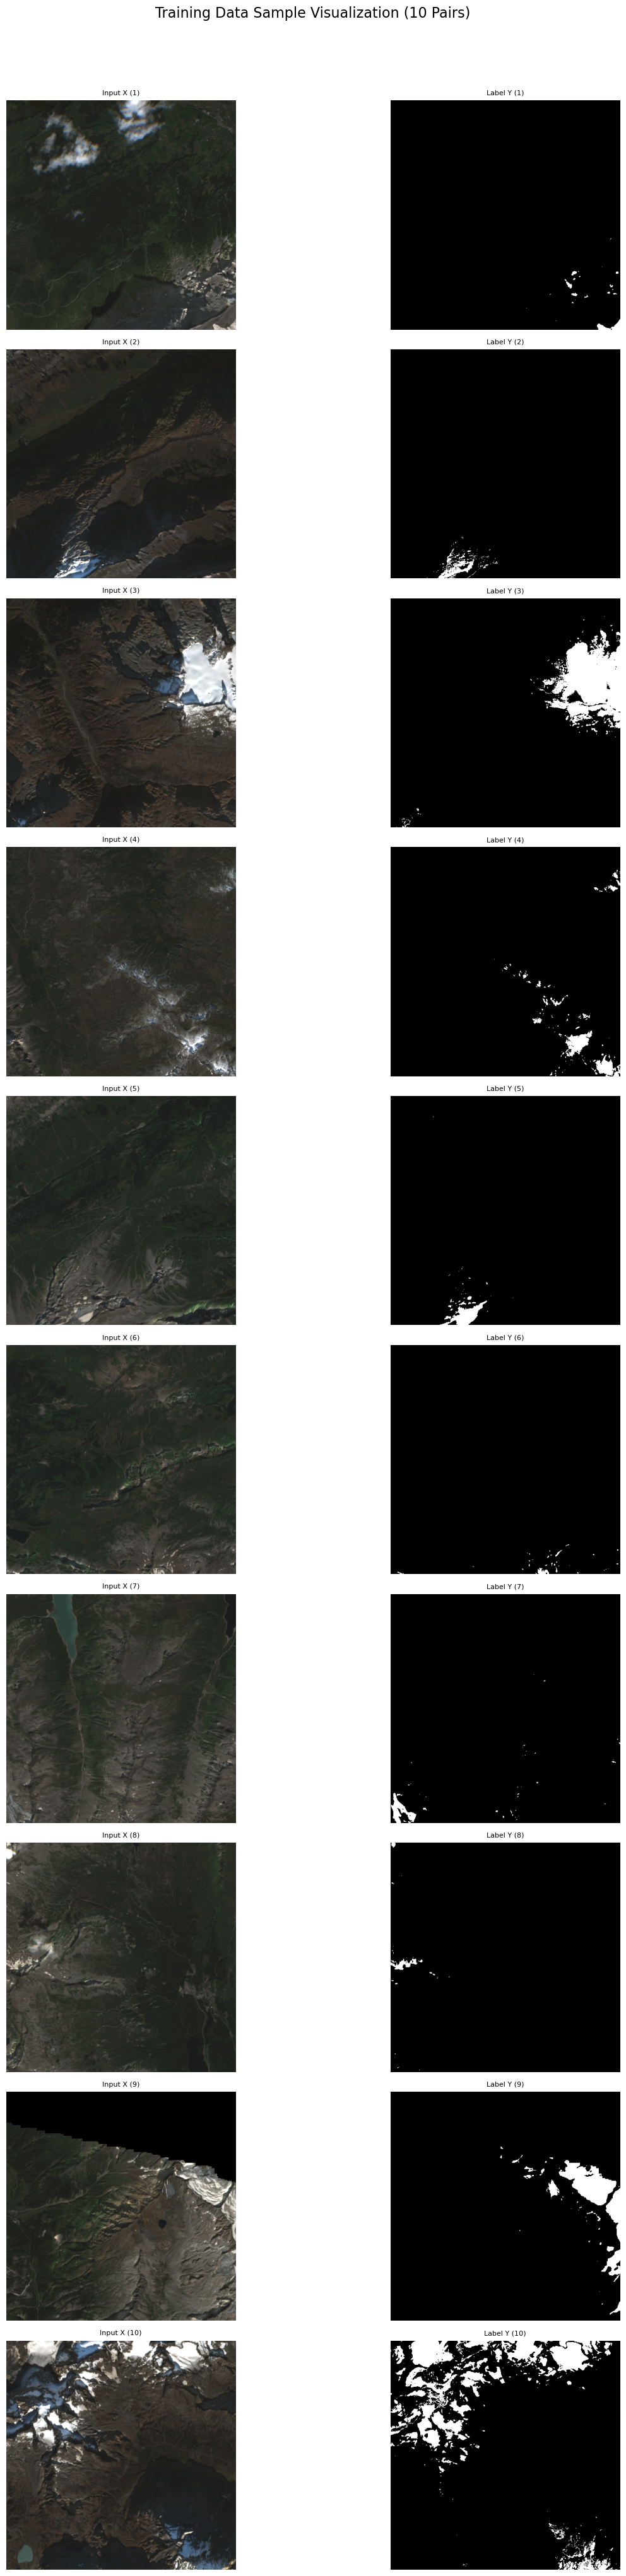

In [4]:
# Visualise some pictures and labels in training set:

# Base directory where the split data is stored
BASE_DIR = 'data_switzerland/preprocessed_data/'

# Directories for the Training set (X and Y must be separate folders)
TRAIN_INPUT_DIR_X = os.path.join(BASE_DIR, 'train', 'X') 
TRAIN_LABEL_DIR_Y = os.path.join(BASE_DIR, 'train', 'Y')

VISUALIZATION_COUNT = 10 # Number of random pairs to display
# ====================================================================

def visualize_training_samples(input_x_dir, label_y_dir, count):
    """
    Selects and displays 'count' random image-label pairs from the training set.

    Args:
        input_x_dir (str): Path to the directory containing training X tiles.
        label_y_dir (str): Path to the directory containing training Y labels.
        count (int): The number of pairs to visualize.
    """
    
    # Find all Input X files in the training directory
    all_x_files = sorted(glob(os.path.join(input_x_dir, '*_X.npy')))

    if not all_x_files:
        print(f"FATAL: No .npy files found in the training input directory: {input_x_dir}")
        print("Please ensure the data split (train/val/test) was executed correctly.")
        return

    # Select a random sample of files
    if len(all_x_files) < count:
        print(f"Warning: Only {len(all_x_files)} tiles available. Displaying all of them.")
        count = len(all_x_files)
        
    selected_x_files = random.sample(all_x_files, count)
    
    # Setup the figure: 'count' rows and 2 columns (Input X and Label Y)
    N_ROWS = count
    N_COLS = 2
    
    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(15, 4 * N_ROWS)) 
    
    fig.suptitle(f"Training Data Sample Visualization ({count} Pairs)", fontsize=16, y=1.02)

    for i, random_x_file in enumerate(selected_x_files):
        # 1. Determine the corresponding Y file path
        base_file_name = os.path.basename(random_x_file)
        label_file_name = base_file_name.replace('_X.npy', '_Y.npy') 
        random_y_file = os.path.join(label_y_dir, label_file_name) 

        if not os.path.exists(random_y_file):
            print(f"Skipping tile {base_file_name}: Corresponding label file not found.")
            continue
        
        try:
            # 2. Load and prepare data
            tile_X = np.load(random_x_file) # (512, 512, 6)
            tile_Y = np.load(random_y_file) # (512, 512, 1)
            
            # Select RGB channels for visualization (Indices 0, 1, 2 in the 6-band stack)
            rgb_tile = tile_X[:, :, [0, 1, 2]] 
            
            # --- Plotting Input X (RGB Image) ---
            axes[i, 0].imshow(rgb_tile)
            axes[i, 0].set_title(f'Input X ({i+1})', fontsize=8)
            axes[i, 0].axis('off')

            # --- Plotting Label Y (Binary Mask) ---
            mask_2d = tile_Y.squeeze() 
            axes[i, 1].imshow(mask_2d, cmap='gray') # White (1) is Ice, Black (0) is Non-Ice
            axes[i, 1].set_title(f'Label Y ({i+1})', fontsize=8)
            axes[i, 1].axis('off')

        except Exception as e:
            print(f"Error loading or plotting data for {base_file_name}: {e}. Skipping.")
            continue
            
    # Adjust layout to prevent overlapping titles
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

# --- EXECUTION ---
visualize_training_samples(TRAIN_INPUT_DIR_X, TRAIN_LABEL_DIR_Y, VISUALIZATION_COUNT)